In [89]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
# Load data and inspect
posts_df = pd.read_csv("data/posts.csv")
posts_df.head(3)

,uri,author_handle,author_did,text,created_at,reply_count,repost_count,quote_count,like_count,is_reply,reply_parent,keyword
0,at://did:plc:rrpnky2otfaua3goqxzlsg2q/app.bsky...,stevesteverers.whaleoilcandles.com,did:plc:rrpnky2otfaua3goqxzlsg2q,I think there's an expert on Twitter you can ask,2026-05-20T14:54:40.483Z,0,0,0,0,True,at://did:plc:4za4evmhsstfh3ex2o37weog/app.bsky...,twitter
1,at://did:plc:abfnjipu7xshc26mudmvripk/app.bsky...,ansel.tv,did:plc:abfnjipu7xshc26mudmvripk,"there's only one ""coffee hack"" you need & it's...",2026-05-20T14:54:37.896Z,1,0,0,0,False,NaN,twitter
2,at://did:plc:egnysgvogtrpyd57haol53sj/app.bsky...,thoughtpunks.com,did:plc:egnysgvogtrpyd57haol53sj,"PSA: This ain't Twitter. So: \n\n1) Your ""Prog...",2026-05-20T14:54:37.493Z,0,0,0,1,False,NaN,twitter


In [91]:
posts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14165 entries, 0 to 14164
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   uri            14165 non-null  str  
 1   author_handle  14165 non-null  str  
 2   author_did     14165 non-null  str  
 3   text           14083 non-null  str  
 4   created_at     14165 non-null  str  
 5   reply_count    14165 non-null  int64
 6   repost_count   14165 non-null  int64
 7   quote_count    14165 non-null  int64
 8   like_count     14165 non-null  int64
 9   is_reply       14165 non-null  bool 
 10  reply_parent   6623 non-null   str  
 11  keyword        14165 non-null  str  
dtypes: bool(1), int64(4), str(7)
memory usage: 1.2 MB


`created_at` is a string, needs to be converted to date time format

In [92]:
# convert created_at to datetime
posts_df['created_at'] = pd.to_datetime(posts_df['created_at'], format='ISO8601')

In [93]:
posts_df.describe()

,reply_count,repost_count,quote_count,like_count
count,14165.000000,14165.000000,14165.000000,14165.000000
mean,1.115708,2.676032,0.271444,16.421532
std,17.730914,84.166718,6.926661,315.295755
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,1.000000,0.000000,0.000000,4.000000
max,1996.000000,9369.000000,641.000000,32757.000000


In [94]:
# Check distribution of replies vs original posts
print(posts_df['is_reply'].value_counts())
print(f"\nReply rate: {posts_df['is_reply'].mean():.1%}")

is_reply
False    7542
True     6623
Name: count, dtype: int64

Reply rate: 46.8%


In [95]:
print(f"Number of unique authors: {posts_df['author_handle'].nunique()}")
print(f"Number of unique posts: {posts_df['uri'].nunique()}")
print(f"Date range: {posts_df['created_at'].min()} to {posts_df['created_at'].max()}")

print(f"Top 20 most active authors: {posts_df['author_handle'].value_counts().head(20)}")

Number of unique authors: 11829
Number of unique posts: 14045
Date range: 2024-12-01 18:34:40.950000+00:00 to 2026-05-20 14:55:12.640000+00:00
Top 20 most active authors: author_handle
charlesgaba.com                  76
edengk.bsky.social               53
semireflection.bsky.social       27
hltv-mirror.eurosky.social       25
eu-people.bsky.social            22
bbcmotdbot.bsky.social           20
handle.invalid                   20
buzzingpop-bot.bsky.social       18
roundsparrow.bsky.social         17
chartdata-bot.bsky.social        14
holdmybooks.bsky.social          11
wwe-x-bot.bsky.social            10
pgl-mirror.eurosky.social        10
bot-unixporn.bsky.social         10
elon.mu.sk                       10
i-like-to-moob-it.bsky.social    10
jacklikesfilms.bsky.social       10
dsards92.bsky.social              9
stevecooganfan.bsky.social        9
chrisconvi.bsky.social            9
Name: count, dtype: int64


Looks like there is some bot accounts in the in the most active posters. e.g.:
- `bbcmotdbot.bsky.social`
- `hltv-mirror.eurosky.social`
- `bot-unixporn.bsky.social ` 

Probably should remove these 

In [96]:
# TODO - check for bot accounts

In [97]:
# Check for duplicates
print(f"{len(posts_df['uri'])} total rows in dataset")
print(f"{posts_df['uri'].nunique()} unique post URIs")

# drop duplicates if any
posts_df = posts_df.drop_duplicates(subset='uri')
print(f"{len(posts_df)} rows remaining after removing duplicates")

14165 total rows in dataset
14045 unique post URIs
14045 rows remaining after removing duplicates


In [98]:
posts_df['reply_count'].value_counts()

reply_count
0       8225
1       4054
2        883
3        315
4        141
5        105
6         59
7         43
10        25
8         24
9         20
11        18
12        15
13        13
20         9
14         9
19         8
15         7
16         7
22         4
33         3
31         3
25         3
41         3
27         3
17         3
26         3
28         2
21         2
23         2
18         2
83         2
56         2
29         2
65         2
48         1
106        1
50         1
131        1
58         1
43         1
116        1
140        1
505        1
44         1
57         1
36         1
24         1
67         1
61         1
68         1
54         1
30         1
64         1
1996       1
135        1
93         1
60         1
62         1
Name: count, dtype: int64

Reply count of 0 and 1 are large, filter those out and we can see the distribution

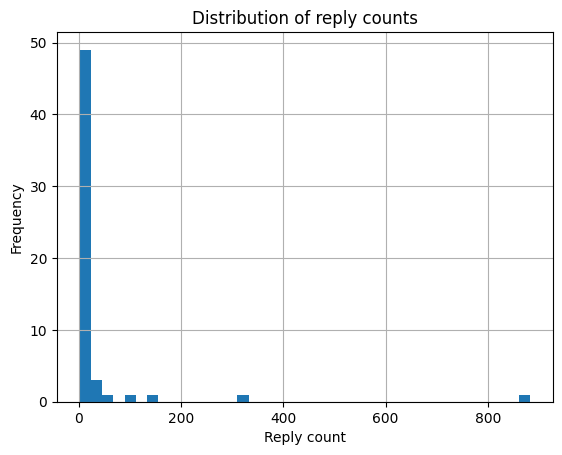

In [99]:
# check reply_count value counts
posts_df[posts_df['reply_count'] > 1]['reply_count'].value_counts().hist(bins=40)
plt.title('Distribution of reply counts')
plt.xlabel('Reply count')
plt.ylabel('Frequency')
plt.show()

Still heavily right skewed, major reply chain is over 800 (vegeta voice)

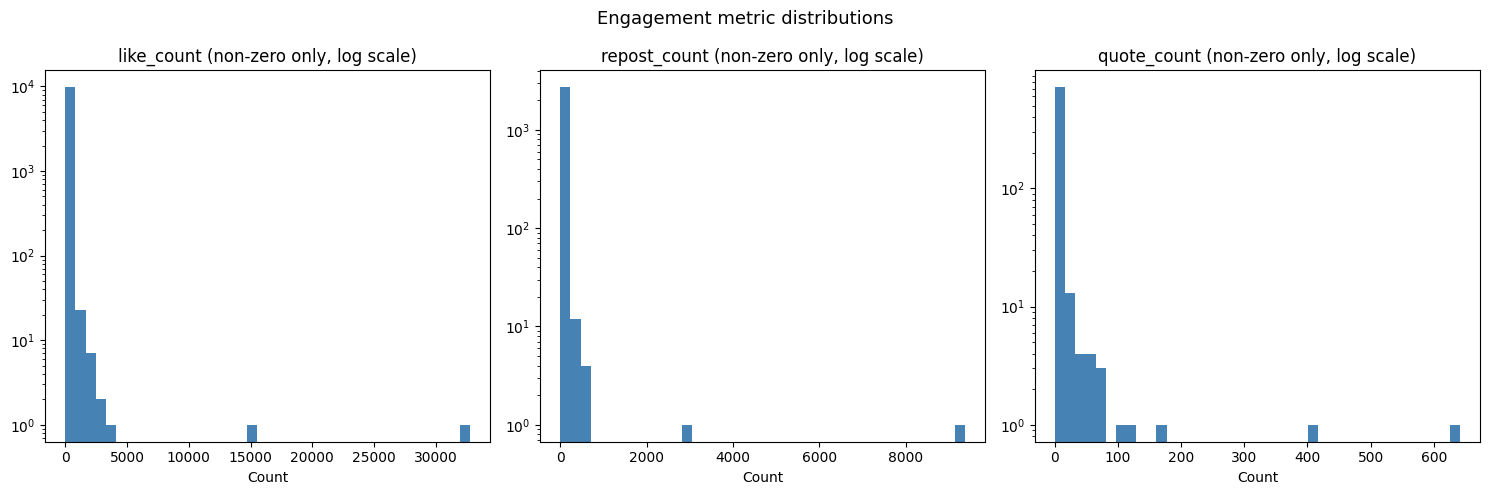

In [100]:
# plot histograms of engagement metrics (likes, reposts, replies, quotes)
num_cols = ['like_count', 'repost_count', 'quote_count']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes.flat, num_cols):
    data = posts_df[col][posts_df[col] > 0]  # exclude zeros for log scale
    ax.hist(data, bins=40, color='steelblue', edgecolor='none')
    ax.set_yscale('log')
    ax.set_title(f'{col} (non-zero only, log scale)')
    ax.set_xlabel('Count')
fig.suptitle('Engagement metric distributions', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/8d/nwt5q5gx0f30dbt1zm5lwl_m0000gn/T/ipykernel_94113/2908618926.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  posts_df['month'] = posts_df['created_at'].dt.to_period('M')


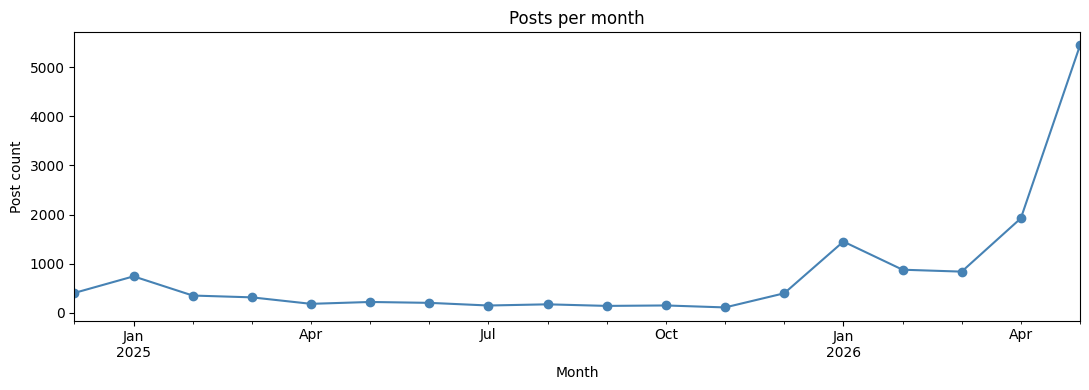

In [101]:
# plot time series plot of posts per month
posts_df['month'] = posts_df['created_at'].dt.to_period('M')
monthly = posts_df.groupby('month').size()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(ax=ax, marker='o', color='steelblue')
ax.set_title('Posts per month')
ax.set_xlabel('Month')
ax.set_ylabel('Post count')
plt.tight_layout()
plt.show()

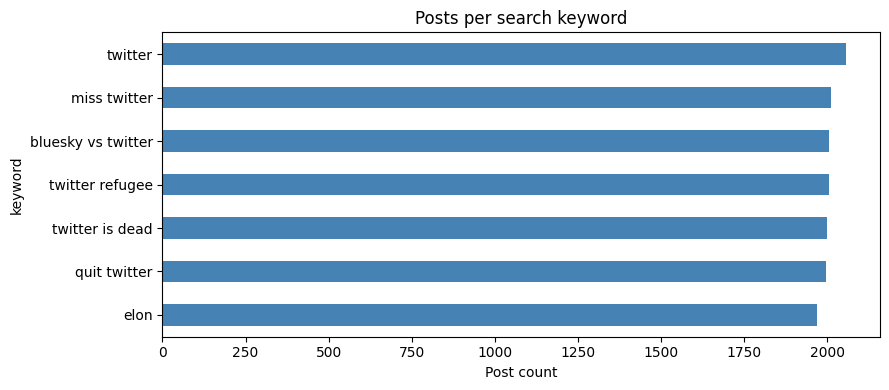

In [102]:
fig, ax = plt.subplots(figsize=(9, 4))
posts_df['keyword'].value_counts().sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Posts per search keyword')
ax.set_xlabel('Post count')
plt.tight_layout()
plt.show()

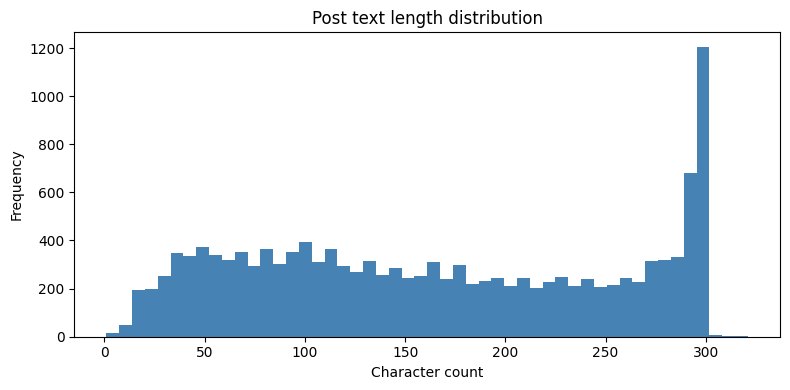

count    13964.0
mean       164.8
std         90.4
min          1.0
25%         86.0
50%        158.0
75%        252.0
max        321.0
Name: text_len, dtype: float64


In [103]:
posts_df['text_len'] = posts_df['text'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(posts_df['text_len'].dropna(), bins=50, color='steelblue', edgecolor='none')
ax.set_title('Post text length distribution')
ax.set_xlabel('Character count')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()
print(posts_df['text_len'].describe().round(1))

In [107]:
# check empty text
empty_mask = posts_df['text'].isna() | (posts_df['text'].str.strip() == '')
print(f"{empty_mask.sum()} empty posts")

81 empty posts


In [7]:
threads = {}

for index, row in posts_df[posts_df['is_reply']].iterrows():
    parent = row['reply_parent']
    if parent not in threads:
        threads[parent] = []
    threads[parent].append(row)

In [ ]:
threads

{'at://did:plc:4za4evmhsstfh3ex2o37weog/app.bsky.feed.post/3mmc4xwfv4s26': [uri              at://did:plc:rrpnky2otfaua3goqxzlsg2q/app.bsky...
  author_handle                   stevesteverers.whaleoilcandles.com
  author_did                        did:plc:rrpnky2otfaua3goqxzlsg2q
  text              I think there's an expert on Twitter you can ask
  created_at                                2026-05-20T14:54:40.483Z
  reply_count                                                      0
  repost_count                                                     0
  quote_count                                                      0
  like_count                                                       0
  is_reply                                                      True
  reply_parent     at://did:plc:4za4evmhsstfh3ex2o37weog/app.bsky...
  keyword                                                    twitter
  Name: 0, dtype: object],
 'at://did:plc:azxqms6di5kwzfyngxnwwrzp/app.bsky.feed.post/3mmbxuazsvs2

In [17]:
len(threads)

6070

In [ ]:
reply_groups = posts_df[posts_df["is_reply"]].groupby("reply_parent")

In [35]:
reply_groups.size()

reply_parent
at://did:plc:222p42fegwhwfyrc3gqam76j/app.bsky.feed.post/3lpkfisyyf22k    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3lrg72y5zkc2r    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3mcaqnlliik2u    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3me24krbdbk2o    1
at://did:plc:222rnvnta2lbl364bog2plxw/app.bsky.feed.post/3mfs3e3lwmc2i    1
                                                                         ..
at://did:plc:zylv4gasp2fj2f6zqnc6n7zk/app.bsky.feed.post/3mm4r3r5gis2s    1
at://did:plc:zys3icn5r7d3m476di4ttao6/app.bsky.feed.post/3mcch4r3o7k27    1
at://did:plc:zzp52njycx34ecru4tgzwk6v/app.bsky.feed.post/3mmb4zxiznc2a    1
at://did:web:didd.uk/app.bsky.feed.post/3mm3n6grfuc2r                     1
at://did:web:jheya.anaproto.xyz/app.bsky.feed.post/3lihsojwpkc2m          1
Length: 6070, dtype: int64

## 